<a href="https://colab.research.google.com/github/daningMontano/ACUS_ECOSYSTEM_FUNCTION_ZCH/blob/main/Notebooks/Carbon/1_Carbon_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Carbon prediction**

By: Daning Montaño Ocampo

Date: 14/4/2026

Model from: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5561821

# **1. Libraries**

In [1]:
import pandas as pd
import numpy as np
import geemap
import ee
import os
import geopandas as gpd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import re
import glob
import rasterio
from scipy import sparse
from scipy.sparse.linalg import spsolve

# **2. Initialize**

In [2]:
# Trigger the authentication flow.
#  Autenticar la cuenta de Google Earth Engine
ee.Authenticate()
ee.Initialize(project='monitoreofpachamama')

# **3. Data**

## 3.1. AOI

In [3]:
aoi =  ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh")

## 3.2. Model XGBoost

In [5]:


# Load the metadata
with open('/content/xgb_metadata.json', 'r') as f:
    xgb_metadata = json.load(f)

# Load the XGBoost model from JSON
bst = xgb.Booster()
bst.load_model('/content/xgb_model.json')

print("XGBoost model and metadata loaded successfully!")

XGBoost model and metadata loaded successfully!


## 3.3. Landsat - Map Biomas

In [ ]:
# Definir los años de interés
years = list(range(2017, 2024))

# Definir las colecciones de mosaicos
mosaic_repo1 = 'projects/mapbiomas-raisg/MOSAICOS/mosaics-2'
mosaic_repo2 = 'projects/mapbiomas-raisg/MOSAICOS/mosaics-pathrow-2'

# Lista para almacenar los mosaicos anuales (Python list)
annual_landsat_mosaics_list = []

for year in years:
    # Filtrar imágenes por año y geometría
    mosaic1_year = ee.ImageCollection(mosaic_repo1).filter(ee.Filter.eq('year', year)).filterBounds(aoi)
    mosaic2_year = ee.ImageCollection(mosaic_repo2).filter(ee.Filter.eq('year', year)).filterBounds(aoi)

    # Combinar los dos conjuntos de datos y hacer un mosaico anual
    median_landsat_year = mosaic1_year.merge(mosaic2_year).median()

    # Obtener los nombres de las bandas (esto solo es necesario una vez, pero se mantiene en el loop para claridad)
    # band_names = median_landsat_year.bandNames().getInfo() # Not strictly needed inside the loop if bands are constant

    median_landsat_select_year = median_landsat_year.select(
        [
            'blue_median',
            'green_dry', 'green_median', 'green_min',
            'red_dry', 'red_median', 'red_min', 'red_wet',
            'nir_dry', 'nir_median', 'nir_min', 'nir_stdDev', 'nir_wet',
            'swir1_dry', 'swir1_median', 'swir1_min', 'swir1_wet',
            'swir2_dry', 'swir2_median', 'swir2_min', 'swir2_wet',
            'gcvi_dry', 'gcvi_median', 'gcvi_wet',
            'evi2_amp', 'evi2_dry', 'evi2_median', 'evi2_stdDev', 'evi2_wet',
            'ndvi_amp', 'ndvi_dry', 'ndvi_median', 'ndvi_stdDev', 'ndvi_wet',
            'savi_dry', 'savi_median', 'savi_stdDev', 'savi_wet',
            'ndmi_dry', 'ndmi_max', 'ndmi_median',
            'ndwi_gao_amp', 'ndwi_gao_dry', 'ndwi_gao_median', 'ndwi_gao_wet'
        ]
    )

    nir = median_landsat_select_year.select("nir_median").toInt32()
    glcm_nir = nir.glcmTexture(**{"size": 5}).select(["nir_median_contrast", "nir_median_ent", "nir_median_var", "nir_median_corr",  "nir_median_diss"])

    swir = median_landsat_select_year.select("swir1_median").toInt32()
    glcm_swir = swir.glcmTexture(**{"size": 5}).select(["swir1_median_contrast", "swir1_median_ent", "swir1_median_var", "swir1_median_corr",  "swir1_median_diss"])

    landsat_combined_year = median_landsat_select_year.addBands(glcm_nir).addBands(glcm_swir).set('year', year)
    annual_landsat_mosaics_list.append(landsat_combined_year)

# Convert the list of images to an ImageCollection
annual_landsat_mosaics = ee.ImageCollection(annual_landsat_mosaics_list)

# Now 'annual_landsat_mosaics' is an ImageCollection where each image is a yearly mosaic

## 3.4. PALSAR 2

In [ ]:
palsar_years = list(range(2017, 2024))

# Lista para almacenar los mosaicos anuales de PALSAR (Python list)
annual_palsar_mosaics_list = []

for year in palsar_years:
    start_date = ee.Date.fromYMD(year, 1, 1)
    end_date = start_date.advance(1, 'year')

    palsar_2 = ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH") \
        .filterDate(start_date, end_date) \
        .filterBounds(aoi)

    palsar_2_mosaic = palsar_2.median()

    # Only proceed if the mosaic is not empty
    if palsar_2_mosaic.bandNames().size().getInfo() > 0:
        DpRVIHH = palsar_2_mosaic.expression(
            '(4.0*HV) / (HH + HV)',
            {
                'HV': palsar_2_mosaic.select('HV'),
                'HH': palsar_2_mosaic.select('HH')
            }
        ).rename("DpRVI")

        RFDI = palsar_2_mosaic.expression(
            '(HH - HV) / (HH + HV)',
            {
                'HV': palsar_2_mosaic.select('HV'),
                'HH': palsar_2_mosaic.select('HH')
            }
        ).rename("RFDI")

        palsar_HV = palsar_2_mosaic.select(['HV']).toInt32()
        glcm = palsar_HV.glcmTexture(**{"size": 5})
        glcm_HV = glcm.select(["HV_contrast", "HV_ent", "HV_var", "HV_corr",  "HV_diss"])

        palsar2_combined_year = palsar_2_mosaic.select('HV','HH').addBands(DpRVIHH).addBands(RFDI).addBands(glcm_HV).set('year', year)
        annual_palsar_mosaics_list.append(palsar2_combined_year)
    else:
        print(f"No PALSAR data found for year {year} within the AOI.")

# Convert the list of images to an ImageCollection
annual_palsar_mosaics = ee.ImageCollection(annual_palsar_mosaics_list)

# Now 'annual_palsar_mosaics' is an ImageCollection where each image is a yearly mosaic

##  3.5. Lat/Lon

In [ ]:
# Coordenadas X, Y
lonlat = ee.Image.pixelLonLat().select(
    ['longitude', 'latitude'], ['X', 'Y']
).clip(aoi.geometry())

## 3.6. DEM - Topography

In [ ]:
dem = ee.Image('USGS/SRTMGL1_003').clip(aoi.geometry())

# Calcular la pendiente (en grados)
slope = ee.Terrain.slope(dem).rename("Slope").clip(aoi.geometry())

## 3.7. Join data

In [ ]:
years = list(range(2017, 2024))

# Define a list to hold the combined annual images
annual_combined_bands_list = []

# Get the list of bands to select from xgb_metadata
bands_to_select = xgb_metadata['features']

for year in years:
    # Get the Landsat image for the current year
    landsat_image = annual_landsat_mosaics.filter(ee.Filter.eq('year', year)).first()
    # Get the PALSAR image for the current year
    palsar_image = annual_palsar_mosaics.filter(ee.Filter.eq('year', year)).first()

    if landsat_image and palsar_image:
        # Combine all bands for the current year
        all_bands_year = landsat_image.addBands(palsar_image).addBands(slope).addBands(dem).addBands(lonlat)

        # Select the common bands across all years and clip to AOI
        bands_selected_year = all_bands_year.select(bands_to_select).clip(aoi.geometry()).set('year', year)
        annual_combined_bands_list.append(bands_selected_year)
    else:
        print(f"Warning: No Landsat or PALSAR data found for year {year}.")

# Convert the list of combined annual images to an ImageCollection
annual_combined_bands = ee.ImageCollection(annual_combined_bands_list)

# Print the band names of the first image in the collection to verify
print(annual_combined_bands.first().bandNames().getInfo())
print(f"Number of annual combined images: {annual_combined_bands.size().getInfo()}")

['X', 'gcvi_median', 'green_min', 'elevation', 'Y', 'HV_corr', 'Slope', 'swir1_median', 'ndmi_dry', 'swir2_dry', 'nir_dry', 'swir1_median_ent', 'HV', 'savi_dry', 'ndwi_gao_amp', 'swir1_median_diss', 'nir_median_diss', 'nir_median_corr', 'DpRVI', 'nir_stdDev', 'swir2_wet', 'nir_median_ent', 'swir1_median_corr', 'HV_var', 'HV_contrast', 'HH', 'red_median', 'green_dry', 'HV_diss', 'evi2_amp', 'swir1_median_var', 'ndvi_wet', 'ndwi_gao_wet', 'nir_wet', 'HV_ent', 'nir_median_var', 'savi_wet']
Number of annual combined images: 7


# **4. Export data**

In [ ]:
for i in range(annual_combined_bands.size().getInfo()):
    image = ee.Image(annual_combined_bands.toList(annual_combined_bands.size()).get(i)).toFloat()
    year = image.get('year').getInfo()

    description = f'combined_data_{year}_30m'
    file_name = f'combined_data_{year}'

    task = ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder='GEE_Exports',
        fileNamePrefix=file_name,
        scale=30,
        region=aoi.geometry(),
        maxPixels=1e13
    )

    task.start()
    print(f'Export task for {year} started: {task.status().get("state")}')
print("All export tasks initiated.")

Export task for 2017 started: READY
Export task for 2018 started: READY
Export task for 2019 started: READY
Export task for 2020 started: READY
Export task for 2021 started: READY
Export task for 2022 started: READY
Export task for 2023 started: READY
All export tasks initiated.


# **5. Make prediction**

## 5.1. Carga las imáganes

In [6]:
from rasterio.merge import merge
import concurrent.futures

drive_path = '/content/drive/MyDrive/'
export_folder = 'GEE_Exports/OPTICAL_SAR_ZAMORA_CH'
full_path = os.path.join(drive_path, export_folder)

if not os.path.exists(full_path):
    print(f"Error: The directory '{full_path}' does not exist.")
else:
    tif_files = glob.glob(os.path.join(full_path, '*.tif'))

    def get_year_from_filename(filepath):
        match = re.search(r'(\d{4})', os.path.basename(filepath))
        return int(match.group(1)) if match else -1

    # Group files by year
    files_by_year = {}
    for f in tif_files:
        y = get_year_from_filename(f)
        if y != -1:
            if y not in files_by_year: files_by_year[y] = []
            files_by_year[y].append(f)

    loaded_images_by_year = {}
    # We need a reference for the profile, so we'll store results to process the first year properly
    results = {}

    def process_year(year, files):
        src_files_to_mosaic = []
        for f in files:
            src = rasterio.open(f)
            src_files_to_mosaic.append(src)

        # Merge all tiles for the current year
        mosaic, out_trans = merge(src_files_to_mosaic)

        # Close source files
        for src in src_files_to_mosaic: src.close()

        print(f"  - Year {year} mosaic completed. Shape: {mosaic.shape}")
        return year, mosaic, out_trans

    print("Mosaicking and loading images by year using multi-threading...")

    with concurrent.futures.ThreadPoolExecutor() as executor:
        future_to_year = {executor.submit(process_year, year, files_by_year[year]): year for year in sorted(files_by_year.keys())}
        for future in concurrent.futures.as_completed(future_to_year):
            year, mosaic, out_trans = future.result()
            loaded_images_by_year[year] = mosaic
            results[year] = (mosaic, out_trans)

    # Set global profile/transform based on the first year (min year)
    min_year = min(files_by_year.keys())
    first_mosaic, first_out_trans = results[min_year]
    with rasterio.open(files_by_year[min_year][0]) as first_src:
        profile = first_src.profile.copy()
        profile.update({
            "height": first_mosaic.shape[1],
            "width": first_mosaic.shape[2],
            "transform": first_out_trans
        })
        source_transform = first_out_trans
        source_crs = first_src.crs

    print("\nAll mosaics ready for prediction.")

Mosaicking and loading images by year using multi-threading...
  - Year 2018 mosaic completed. Shape: (37, 6216, 3951)
  - Year 2019 mosaic completed. Shape: (37, 6216, 3951)
  - Year 2021 mosaic completed. Shape: (37, 6216, 3951)
  - Year 2023 mosaic completed. Shape: (37, 6216, 3951)
  - Year 2017 mosaic completed. Shape: (37, 6216, 3951)
  - Year 2020 mosaic completed. Shape: (37, 6216, 3951)
  - Year 2022 mosaic completed. Shape: (37, 6216, 3951)

All mosaics ready for prediction.


In [7]:
import gc
import sys

# 1. Forzar la recolección de basura inmediatamente
gc.collect()

# 2. Limpiar el historial de salidas (Out) de IPython
# Esto elimina las referencias internas a objetos grandes que mostraste en celdas previas
get_ipython().perform_usage_error_display = False
get_ipython().run_line_magic('reset', '-f out')

# 3. Vaciar explícitamente el diccionario de resultados de la sesión
Out.clear()

print("Memoria RAM y caché de resultados liberados con éxito.")

Flushing output cache (0 entries)
Memoria RAM y caché de resultados liberados con éxito.


## 5.2. Hacer predicciones

In [8]:
import concurrent.futures
import numpy as np

import pandas as pd
import xgboost as xgb
import rasterio
import gc

# Get feature names from metadata
feature_names = xgb_metadata['features']

def predict_year(year, image_data_bands_hw):
    try:
        current_bands, current_height, current_width = image_data_bands_hw.shape
        # Use float32 to save memory compared to float64
        predicted_image = np.full((current_height, current_width), np.nan, dtype=np.float32)

        with rasterio.open(files_by_year[year][0]) as src:
            band_names_in_tif = src.descriptions

        # Process in chunks of rows to keep RAM low
        chunk_size = 500
        for start_row in range(0, current_height, chunk_size):
            end_row = min(start_row + chunk_size, current_height)

            # Extract chunk and transpose to (pixels, bands)
            chunk = image_data_bands_hw[:, start_row:end_row, :]
            chunk_reshaped = chunk.transpose(1, 2, 0).reshape(-1, current_bands)

            df_chunk = pd.DataFrame(chunk_reshaped, columns=band_names_in_tif)
            data_for_prediction = df_chunk[feature_names]

            valid_mask = data_for_prediction.notna().all(axis=1)
            if valid_mask.any():
                dmatrix = xgb.DMatrix(data_for_prediction[valid_mask].values)
                preds = bst.predict(dmatrix)

                chunk_preds = np.full(chunk_reshaped.shape[0], np.nan, dtype=np.float32)
                chunk_preds[valid_mask.values] = preds
                predicted_image[start_row:end_row, :] = chunk_preds.reshape(end_row - start_row, current_width)

            del df_chunk, chunk_reshaped, data_for_prediction

        print(f"  - Predictions completed for year {year}.")
        return year, predicted_image
    except Exception as e:
        print(f"Error predicting for year {year}: {e}")
        return year, None
    finally:
        gc.collect()

predicted_carbon_by_year = {}
print("Making predictions using memory-efficient batching...")

# Limit max_workers to avoid concurrent RAM spikes
with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
    future_to_pred = {executor.submit(predict_year, year, img): year for year, img in loaded_images_by_year.items()}
    for future in concurrent.futures.as_completed(future_to_pred):
        year, result = future.result()
        if result is not None:
            predicted_carbon_by_year[year] = result

print(f"\nAll predictions completed. Years: {list(predicted_carbon_by_year.keys())}")

Making predictions using memory-efficient batching...
  - Predictions completed for year 2018.
  - Predictions completed for year 2019.
  - Predictions completed for year 2021.
  - Predictions completed for year 2023.
  - Predictions completed for year 2017.
  - Predictions completed for year 2020.
  - Predictions completed for year 2022.

All predictions completed. Years: [2018, 2019, 2021, 2023, 2017, 2020, 2022]


## 5.3. Plot maps

Generating carbon prediction maps for each year...


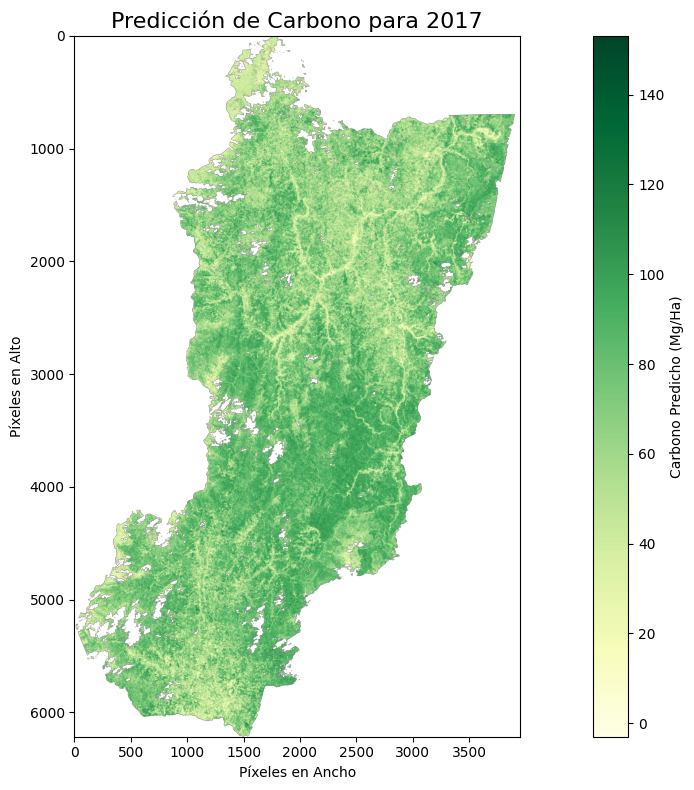

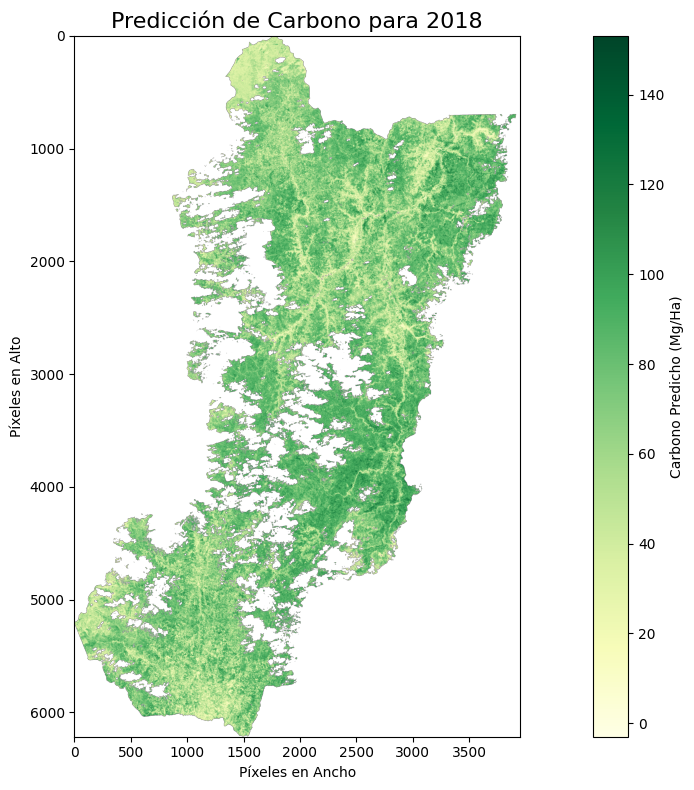

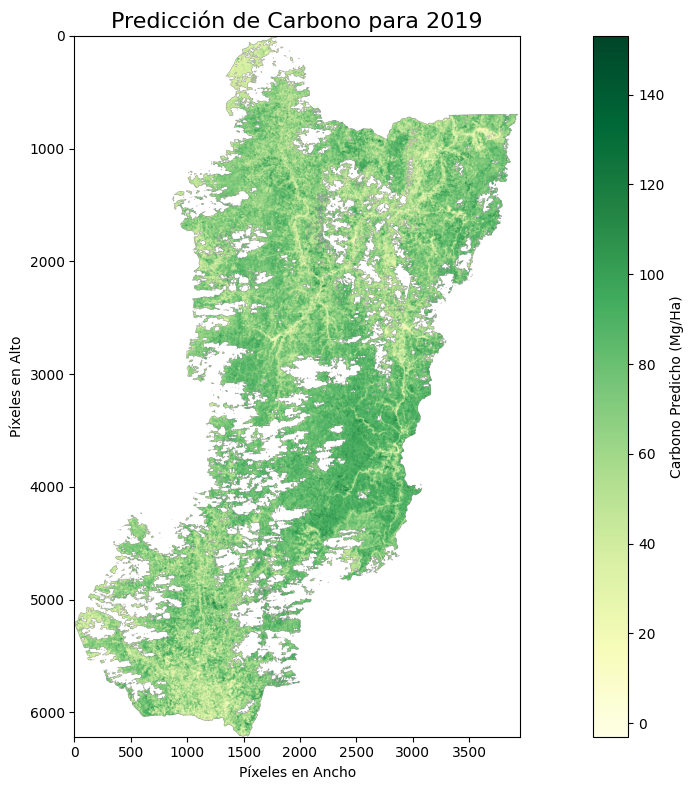

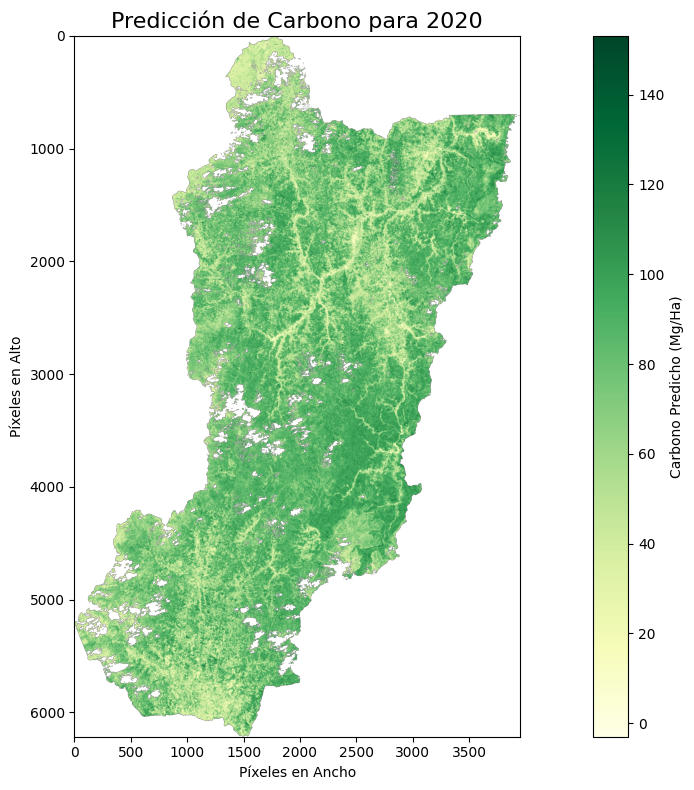

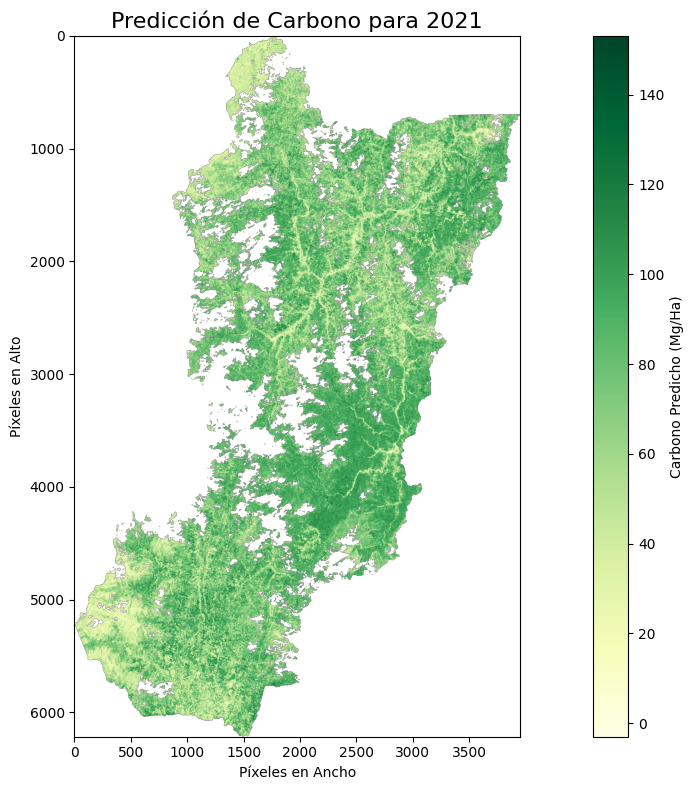

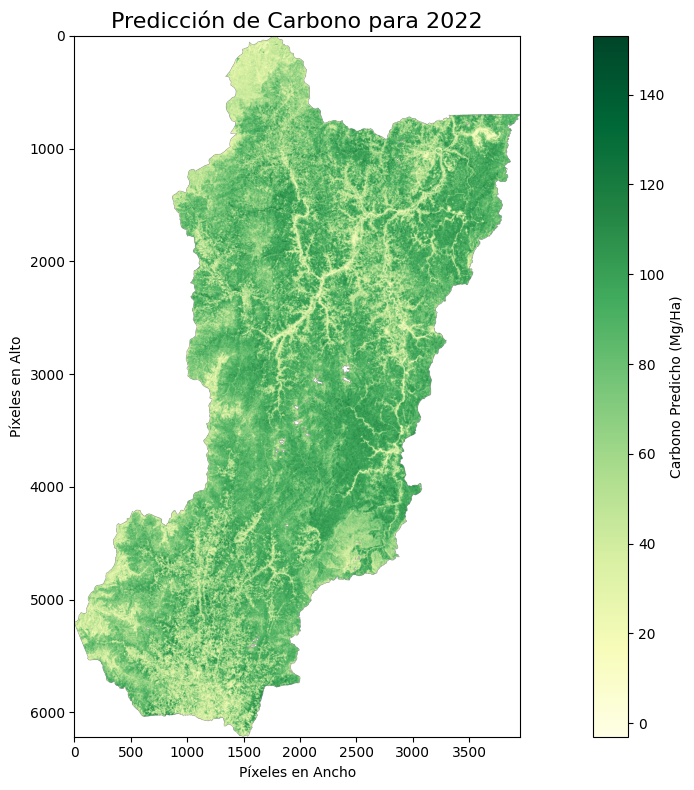

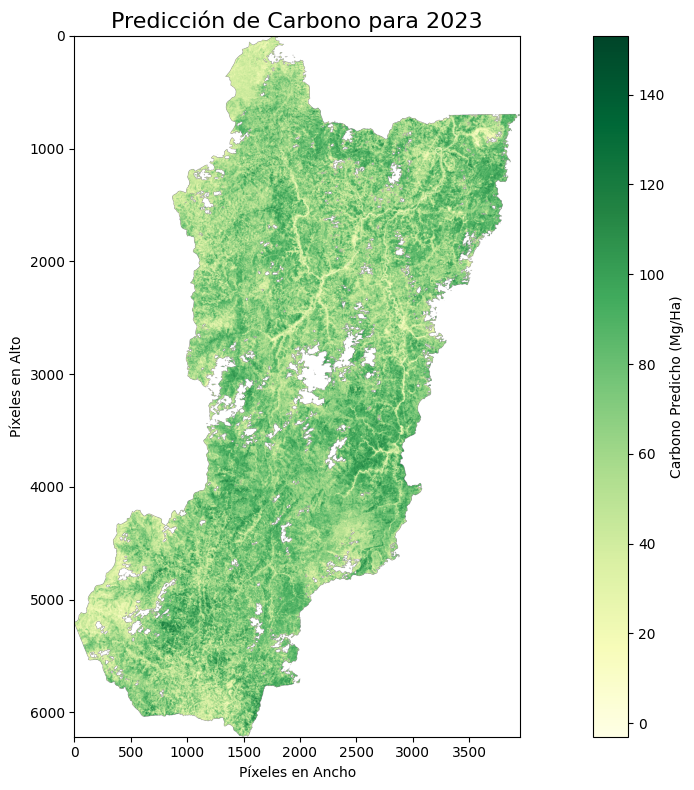

All carbon prediction maps have been generated.


In [9]:


print("Generating carbon prediction maps for each year...")

# Get the list of years with predictions
years_with_predictions = sorted(predicted_carbon_by_year.keys())

if not years_with_predictions:
    print("No predictions available to plot.")
else:
    # Determine a global min/max for consistent colorbar across all plots
    all_predictions = []
    for year in years_with_predictions:
        # Filter out NaNs for min/max calculation
        valid_data = predicted_carbon_by_year[year][~np.isnan(predicted_carbon_by_year[year])]
        if valid_data.size > 0:
            all_predictions.extend(valid_data)

    if all_predictions:
        global_vmin = np.min(all_predictions)
        global_vmax = np.max(all_predictions)
    else:
        global_vmin = None
        global_vmax = None

    # Plot each year's prediction
    for year in years_with_predictions:
        predicted_image = predicted_carbon_by_year[year]

        plt.figure(figsize=(15, 8)) # Adjust figure size as needed

        # Use imshow to display the prediction map
        # Set vmin/vmax for a consistent color scale across all years
        # Choose a colormap, e.g., 'viridis', 'YlGn', 'hot', 'jet'
        img = plt.imshow(predicted_image, cmap='YlGn', origin='upper',
                         vmin=global_vmin, vmax=global_vmax)

        plt.colorbar(img, label='Carbono Predicho (Mg/Ha)')
        plt.title(f'Predicción de Carbono para {year}', fontsize=16)
        plt.xlabel('Píxeles en Ancho')
        plt.ylabel('Píxeles en Alto')
        plt.tight_layout()
        plt.show()

print("All carbon prediction maps have been generated.")


Boxplot

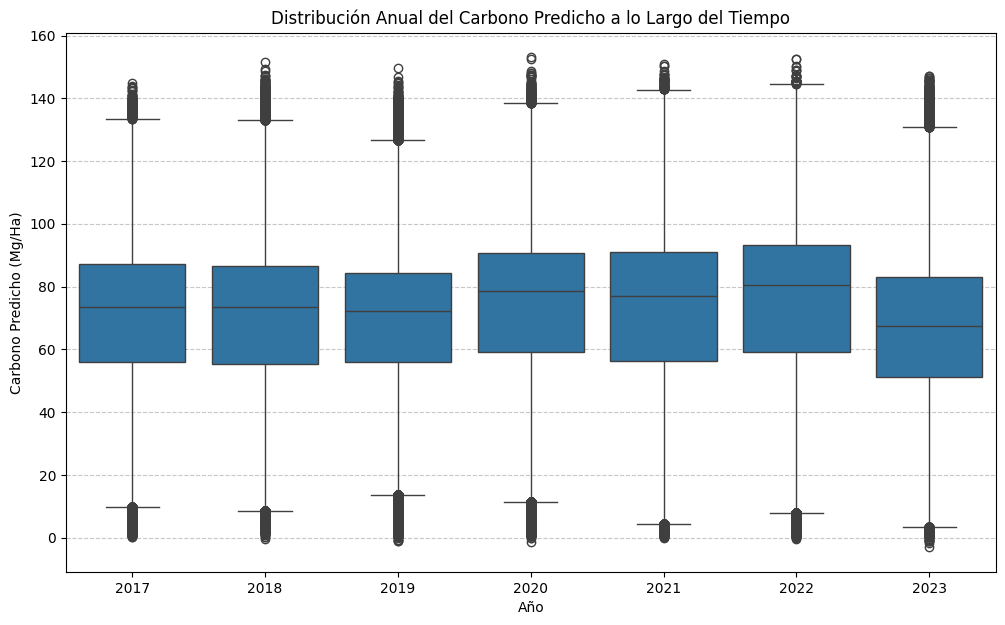

In [ ]:


# Create a list to store data for the boxplot
boxplot_data = []

# Iterate through the predicted carbon data for each year
for year, predicted_image in predicted_carbon_by_year.items():
    # Flatten the 2D array and remove NaN values
    valid_carbon_values = predicted_image[~np.isnan(predicted_image)].flatten()

    # Create a temporary DataFrame for the current year's data
    df_year = pd.DataFrame({
        'Year': year,
        'Carbono Predicho (Mg/Ha)': valid_carbon_values
    })
    boxplot_data.append(df_year)

# Concatenate all yearly DataFrames into a single DataFrame
if boxplot_data:
    full_boxplot_df = pd.concat(boxplot_data)

    # Create the annual boxplot
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Year', y='Carbono Predicho (Mg/Ha)', data=full_boxplot_df)
    plt.title('Distribución Anual del Carbono Predicho a lo Largo del Tiempo')
    plt.xlabel('Año')
    plt.ylabel('Carbono Predicho (Mg/Ha)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No hay datos de carbono predicho disponibles para generar el boxplot.")


In [10]:
import os
import numpy as np
import rasterio

# Ensure Google Drive is mounted (if not already)
# from google.colab import drive
# drive.mount('/content/drive')

# Define the output folder in Google Drive for filtered predictions
drive_path = '/content/drive/MyDrive/'
export_folder_filtered = 'GEE_Exports/OPTICAL_SAR_ZAMORA_CH/Filtered_Carbon_Export'
full_export_path_filtered = os.path.join(drive_path, export_folder_filtered)

# Create the directory if it doesn't exist
os.makedirs(full_export_path_filtered, exist_ok=True)
print(f"Output directory for filtered data: {full_export_path_filtered}")

# Check if source_crs and source_transform are available from earlier steps
# These variables are expected to be defined after running cell `UsP34OpgWxIk` (5.1. Carga las imáganes)
if 'source_crs' not in locals() or 'source_transform' not in locals() or 'profile' not in locals():
    print("Error: CRS, transform, or profile information not found. Please ensure previous cells (especially those in section 5.1 and 5.2) have been run.")
else:
    print("Exporting filtered carbon prediction maps...")
    # The `predicted_carbon_by_year` variable contains the filtered predictions after cell `tif6Ws_Ygvv-`
    for year, predicted_image in predicted_carbon_by_year.items():
        output_filename = f'filtered_carbon_prediction_{year}.tif'
        output_filepath = os.path.join(full_export_path_filtered, output_filename)

        # Update the profile for the output GeoTIFF
        output_profile = profile.copy()
        output_profile.update({
            'driver': 'GTiff',
            'height': predicted_image.shape[0],
            'width': predicted_image.shape[1],
            'count': 1,  # Single band output
            'dtype': predicted_image.dtype, # Use the dtype of the prediction array
            'crs': source_crs,
            'transform': source_transform,
            'nodata': np.nan # Set NaN as nodata value
        })

        try:
            with rasterio.open(output_filepath, 'w', **output_profile) as dst:
                dst.write(predicted_image, 1) # Write the single band
            print(f"  - Exported '{output_filename}' successfully.")
        except Exception as e:
            print(f"Error exporting '{output_filename}': {e}")

    print("All filtered carbon prediction maps have been exported.")

Output directory for filtered data: /content/drive/MyDrive/GEE_Exports/OPTICAL_SAR_ZAMORA_CH/Filtered_Carbon_Export
Exporting filtered carbon prediction maps...
  - Exported 'filtered_carbon_prediction_2018.tif' successfully.
  - Exported 'filtered_carbon_prediction_2019.tif' successfully.
  - Exported 'filtered_carbon_prediction_2021.tif' successfully.
  - Exported 'filtered_carbon_prediction_2023.tif' successfully.
  - Exported 'filtered_carbon_prediction_2017.tif' successfully.
  - Exported 'filtered_carbon_prediction_2020.tif' successfully.
  - Exported 'filtered_carbon_prediction_2022.tif' successfully.
All filtered carbon prediction maps have been exported.


## 5.4 Spatio-Temporal filter

In [15]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import os
import glob
import rasterio
import re

# Define the Whittaker smoother function for a single 1D time series
def whittaker_smoother_1D(y, lambda_=500.0, d=2):
    """
    Applies Whittaker smoother to a 1D array (time series), handling NaNs.
    """
    m = len(y)
    if m <= d or np.all(np.isnan(y)):
        return np.full_like(y, np.nan, dtype=np.float32)

    weights = np.where(np.isnan(y), 0.0, 1.0)
    y_filled = np.nan_to_num(y, nan=0.0) # Using 0.0 for NaNs to build the system
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(m - 2, m)).tocsc()
    W = sparse.diags(weights, 0, shape=(m, m), format='csc')
    A = W + lambda_ * (D.transpose() @ D)
    b = W @ y_filled
    smoothed_y = spsolve(A, b)
    return smoothed_y.astype(np.float32)

# --- Start of modifications to load data from disk ---
print("Loading unfiltered prediction rasters from disk for Whittaker smoothing...")

drive_path = '/content/drive/MyDrive/'
# This path refers to the output of cell y-eUeOY0B-EZ, which contains the
# initially predicted (unfiltered) carbon maps.
export_folder_unfiltered_predictions = 'GEE_Exports/OPTICAL_SAR_ZAMORA_CH/Filtered_Carbon_Export'
full_path_unfiltered = os.path.join(drive_path, export_folder_unfiltered_predictions)

predictions_from_disk_for_smoothing = {}
if os.path.exists(full_path_unfiltered):
    tif_files = glob.glob(os.path.join(full_path_unfiltered, '*.tif'))

    def get_year_from_filename(filepath):
        # Corrected regex to match four digits for the year
        match = re.search(r'(\d{4})', os.path.basename(filepath))
        return int(match.group(1)) if match else -1

    for f in tif_files:
        year = get_year_from_filename(f)
        if year != -1:
            with rasterio.open(f) as src:
                # Assuming the carbon prediction is in the first band
                predictions_from_disk_for_smoothing[year] = src.read(1).astype(np.float32)
            print(f"  - Loaded {os.path.basename(f)} for year {year}")
else:
    print(f"Error: Directory '{full_path_unfiltered}' not found. Cannot load predictions for smoothing.")

# Now, use predictions_from_disk_for_smoothing for the smoothing process
# The original 'predicted_carbon_by_year' variable will be updated with the smoothed results.
# This ensures that the subsequent export step (cell Ng2FFfxbldHm) exports the filtered data.
if not predictions_from_disk_for_smoothing:
    print("No carbon prediction data loaded from disk for smoothing.")
else:
    # Convert dictionary of 2D arrays into a 3D NumPy array
    years_list = sorted(predictions_from_disk_for_smoothing.keys())
    num_years = len(years_list)

    if not years_list or not predictions_from_disk_for_smoothing[years_list[0]].size > 0:
        print("No carbon prediction data available for smoothing after loading from disk.")
    else:
        height, width = predictions_from_disk_for_smoothing[years_list[0]].shape
        carbon_3d_array = np.full((num_years, height, width), np.nan, dtype=np.float32)

        for i, year in enumerate(years_list):
            carbon_3d_array[i, :, :] = predictions_from_disk_for_smoothing[year]

        print("Applying temporal Whittaker smoother with lower lambda (50.0) for increased sensitivity to changes...")

        # Ajustamos lambda a 50.0 para mayor sensibilidad a cambios y detección de quiebres
        whittaker_lambda = 50.0
        whittaker_d = 2

        filtered_carbon_3d_array = np.full_like(carbon_3d_array, np.nan, dtype=np.float32)

        for h in range(height):
            for w in range(width):
                time_series = carbon_3d_array[:, h, w]
                smoothed_series = whittaker_smoother_1D(time_series, lambda_=whittaker_lambda, d=whittaker_d)
                filtered_carbon_3d_array[:, h, w] = smoothed_series

        # Update the global predicted_carbon_by_year with the filtered results
        global predicted_carbon_by_year # Declare global to modify the variable from other cells
        predicted_carbon_by_year = {} # Clear previous content
        for i, year in enumerate(years_list):
            predicted_carbon_by_year[year] = filtered_carbon_3d_array[i, :, :]

        print("Temporal Whittaker smoother applied successfully using data loaded from disk. Re-run your plots to see the result.")

# --- End of modifications ---

Loading unfiltered prediction rasters from disk for Whittaker smoothing...
  - Loaded filtered_carbon_prediction_2018.tif for year 2018
  - Loaded filtered_carbon_prediction_2019.tif for year 2019
  - Loaded filtered_carbon_prediction_2021.tif for year 2021
  - Loaded filtered_carbon_prediction_2023.tif for year 2023
  - Loaded filtered_carbon_prediction_2017.tif for year 2017
  - Loaded filtered_carbon_prediction_2020.tif for year 2020
  - Loaded filtered_carbon_prediction_2022.tif for year 2022
Applying temporal Whittaker smoother with lower lambda (50.0) for increased sensitivity to changes...


/tmp/ipykernel_5266/4135936255.py:24: MatrixRankWarning: Matrix is exactly singular
  smoothed_y = spsolve(A, b)


Temporal Whittaker smoother applied successfully using data loaded from disk. Re-run your plots to see the result.


## 5.4. Export predictions

In [16]:

# Ensure Google Drive is mounted (if not already)
# from google.colab import drive
# drive.mount('/content/drive')

# Define the output folder in Google Drive for filtered predictions
drive_path = '/content/drive/MyDrive/'
export_folder_filtered = 'GEE_Exports/OPTICAL_SAR_ZAMORA_CH/Filtered_Carbon_smooth'
full_export_path_filtered = os.path.join(drive_path, export_folder_filtered)

# Create the directory if it doesn't exist
os.makedirs(full_export_path_filtered, exist_ok=True)
print(f"Output directory for filtered data: {full_export_path_filtered}")

# Check if source_crs and source_transform are available from earlier steps
if 'source_crs' not in locals() or 'source_transform' not in locals():
    print("Error: CRS and transform information not found. Please ensure previous cells (5.2 Make predictions) have been run.")
else:
    print("Exporting filtered carbon prediction maps...")
    for year, predicted_image in predicted_carbon_by_year.items():
        output_filename = f'filtered_carbon_prediction_{year}.tif'
        output_filepath = os.path.join(full_export_path_filtered, output_filename)

        # Update the profile for the output GeoTIFF
        # Assuming single band output (carbon prediction)
        output_profile = profile.copy()
        output_profile.update({
            'driver': 'GTiff',
            'height': predicted_image.shape[0],
            'width': predicted_image.shape[1],
            'count': 1,  # Single band output
            'dtype': predicted_image.dtype, # Use the dtype of the prediction array
            'crs': source_crs,
            'transform': source_transform,
            'nodata': np.nan # Set NaN as nodata value
        })

        try:
            with rasterio.open(output_filepath, 'w', **output_profile) as dst:
                dst.write(predicted_image, 1) # Write the single band
            print(f"  - Exported '{output_filename}' successfully.")
        except Exception as e:
            print(f"Error exporting '{output_filename}': {e}")

    print("All filtered carbon prediction maps have been exported.")


Output directory for filtered data: /content/drive/MyDrive/GEE_Exports/OPTICAL_SAR_ZAMORA_CH/Filtered_Carbon_smooth
Exporting filtered carbon prediction maps...
  - Exported 'filtered_carbon_prediction_2017.tif' successfully.
  - Exported 'filtered_carbon_prediction_2018.tif' successfully.
  - Exported 'filtered_carbon_prediction_2019.tif' successfully.
  - Exported 'filtered_carbon_prediction_2020.tif' successfully.
  - Exported 'filtered_carbon_prediction_2021.tif' successfully.
  - Exported 'filtered_carbon_prediction_2022.tif' successfully.
  - Exported 'filtered_carbon_prediction_2023.tif' successfully.
All filtered carbon prediction maps have been exported.
